In [15]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 3.6 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 2.9 MB/s  0:00:12m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [18]:
# 1. LOAD THE DATA
try:
    df = pd.read_csv('/home/navnit/Projects/Data_Analytics/Project_Credit_Fruad/data/creditcard.csv')
    print("Data Loaded Successfully!")
except FileNotFoundError:
    print("Error: CSV file not found. Check your folder path.")

Data Loaded Successfully!


In [19]:
# 2. INITIAL INSPECTION
print("\n--- Dataset Shape ---")
print(df.shape) 

print("\n--- Column Information ---")
print(df.info())

print("\n--- Statistical Summary ---")
print(df.describe())


--- Dataset Shape ---
(284807, 31)

--- Column Information ---
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64


In [20]:

# 3. CHECKING FOR MISSING VALUES
print("\n--- Missing Values ---")
print(df.isnull().sum().max())


--- Missing Values ---
0


In [21]:
# 4. CLASS DISTRIBUTION
fraud_count = df['Class'].value_counts()
fraud_percentage = (fraud_count[1] / len(df)) * 100

print(f"\nLegit Transactions (0): {fraud_count[0]}")
print(f"Fraud Transactions (1): {fraud_count[1]}")
print(f"Percentage of Fraud: {fraud_percentage:.3f}%")


Legit Transactions (0): 284315
Fraud Transactions (1): 492
Percentage of Fraud: 0.173%


/tmp/ipykernel_258174/3060406206.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='viridis')


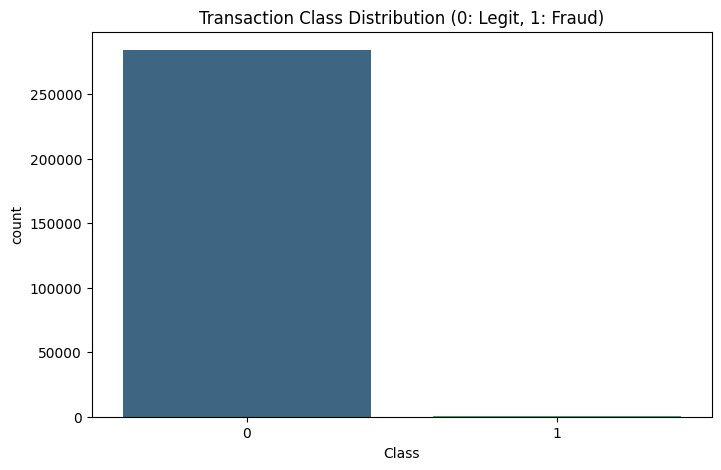

In [22]:
# 5. VISUALIZATION: Class Imbalance
plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=df, palette='viridis')
plt.title('Transaction Class Distribution (0: Legit, 1: Fraud)')
plt.show()

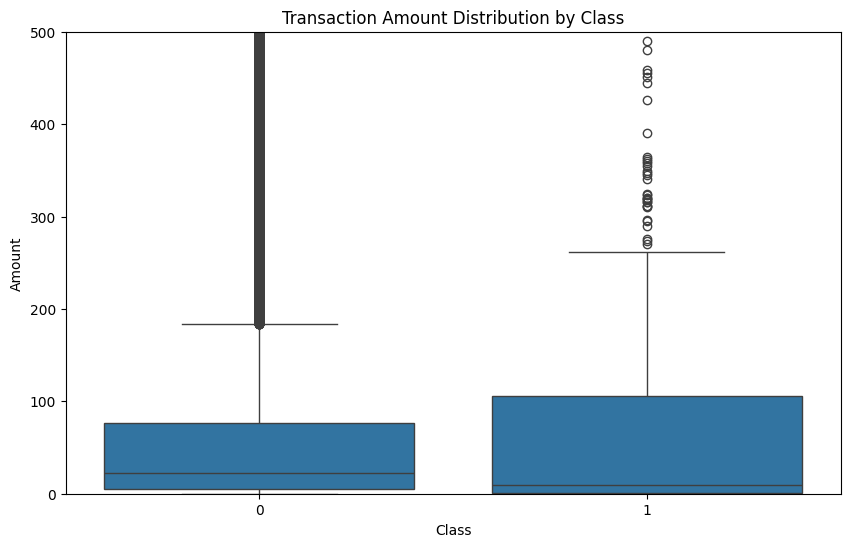

In [23]:
# 6. VISUALIZATION: Amount vs. Fraud
plt.figure(figsize=(10, 6))
sns.boxplot(x='Class', y='Amount', data=df)
plt.ylim(0, 500)
plt.title('Transaction Amount Distribution by Class')
plt.show()

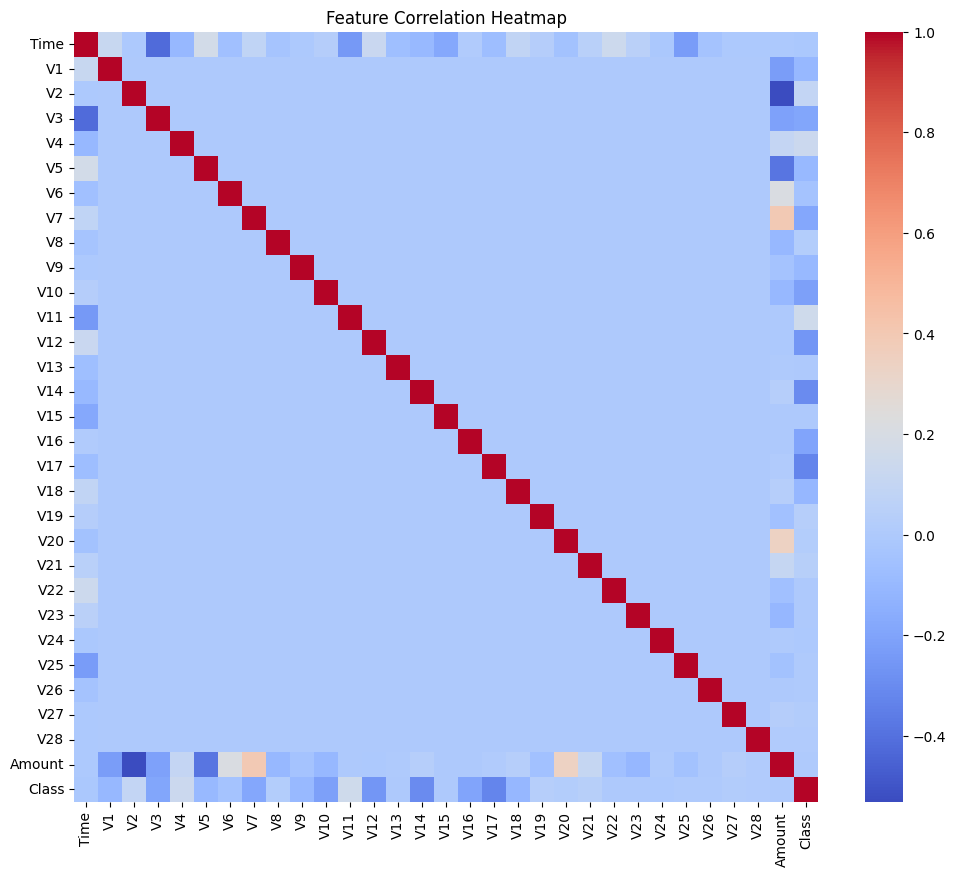

In [24]:

# 7. FEATURE CORRELATION (Heatmap)
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

In [25]:

# 8. DATA PREPARATION FOR PHASE 2
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))

# Drop the old unscaled columns
df.drop(['Time', 'Amount'], axis=1, inplace=True)


In [26]:
# 9. EXPORT CLEANED DATA FOR POWER BI
# This CSV will be the source for your Phase 2 Dashboard
df.to_csv('cleaned_fraud_data.csv', index=False)
print("\n✅ Cleaned data exported as 'cleaned_fraud_data.csv'")


✅ Cleaned data exported as 'cleaned_fraud_data.csv'
